In [1]:
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DATA_DIR = "data"   # must contain train/ and test/
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.14.1
GPU available: False


In [2]:
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    for emotion in sorted(os.listdir(f"{DATA_DIR}/{split}")):
        n = len(os.listdir(f"{DATA_DIR}/{split}/{emotion}"))
        print(f"  {emotion:10s} {n}")


TRAIN
  angry      3995
  disgust    436
  fear       4097
  happy      7215
  neutral    4965
  sad        4830
  surprise   3171

TEST
  angry      958
  disgust    111
  fear       1024
  happy      1774
  neutral    1233
  sad        1247
  surprise   831


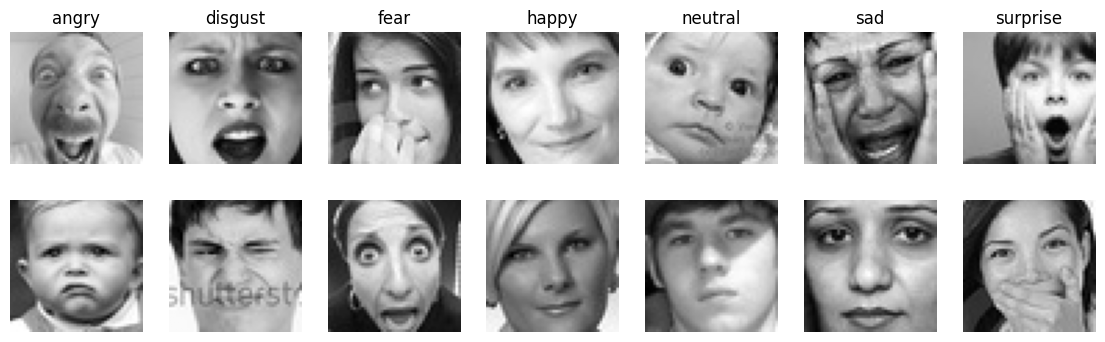

In [3]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for col, emotion in enumerate(sorted(os.listdir(f"{DATA_DIR}/train"))):
    folder = f"{DATA_DIR}/train/{emotion}"
    for row in range(2):
        img = plt.imread(f"{folder}/{os.listdir(folder)[row]}")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(emotion)
plt.show()

In [4]:
IMG_SIZE = 48

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

test_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

In [5]:
train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", train_transform)
test_ds  = datasets.ImageFolder(f"{DATA_DIR}/test",  test_transform)

print("Classes:", train_ds.classes)
print("Train images:", len(train_ds), "| Test images:", len(test_ds))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64)

images, labels = next(iter(train_dl))
print("Batch shape:", images.shape)
print("Labels:", labels[:10])

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train images: 28709 | Test images: 7178
Batch shape: torch.Size([64, 1, 48, 48])
Labels: tensor([0, 2, 3, 0, 4, 4, 3, 4, 2, 5])


In [6]:
import torch.nn as nn

def conv_block(cin, cout):
    layers = []
    for i in range(2):
        layers += [
            nn.Conv2d(cin if i == 0 else cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        ]
    layers += [nn.MaxPool2d(2), nn.Dropout(0.25)]
    return nn.Sequential(*layers)

In [7]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [8]:
model = EmotionCNN(num_classes=7)

x = images                      # the batch from Step 5
for i, block in enumerate(model.features):
    x = block(x)
    print(f"After block {i+1}: {tuple(x.shape)}")

out = model(images)
print("Final output:", tuple(out.shape))

total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {total:,}")

After block 1: (64, 32, 24, 24)
After block 2: (64, 64, 12, 12)
After block 3: (64, 128, 6, 6)
After block 4: (64, 256, 3, 3)
Final output: (64, 7)
Trainable parameters: 1,240,231


In [9]:
import math

criterion = nn.CrossEntropyLoss()
model.eval()
with torch.no_grad():
    logits = model(images)
    loss = criterion(logits, labels)

print(f"Loss of untrained model: {loss.item():.3f}")
print(f"Expected if guessing randomly: {math.log(7):.3f}")

Loss of untrained model: 1.933
Expected if guessing randomly: 1.946


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

model = EmotionCNN(num_classes=7).to(device)

counts = torch.bincount(torch.tensor(train_ds.targets)).float()
weights = (counts.sum() / (len(counts) * counts)).to(device)
print("Class weights:", dict(zip(train_ds.classes, weights.cpu().numpy().round(2))))

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Using: cpu
Class weights: {'angry': np.float32(1.03), 'disgust': np.float32(9.41), 'fear': np.float32(1.0), 'happy': np.float32(0.57), 'neutral': np.float32(0.83), 'sad': np.float32(0.85), 'surprise': np.float32(1.29)}


In [11]:
def evaluate(model, loader):
    model.eval()                    # turns off dropout, uses fixed BatchNorm stats
    correct, total = 0, 0
    with torch.no_grad():           # no gradients needed, saves memory and time
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)   # index of highest score
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [12]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()           # clear old gradients
        loss = criterion(model(x), y)   # forward pass + loss
        loss.backward()                 # compute gradients
        optimizer.step()                # update weights

        running_loss += loss.item() * y.size(0)
    return running_loss / len(loader.dataset)

In [13]:
import time

model.train()
start = time.time()
for i, (x, y) in enumerate(train_dl):
    if i == 10:
        break
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    criterion(model(x), y).backward()
    optimizer.step()

per_batch = (time.time() - start) / 10
print(f"{per_batch:.2f}s per batch -> about {per_batch * len(train_dl) / 60:.1f} min per epoch")


0.21s per batch -> about 1.5 min per epoch


In [14]:
EPOCHS = 3
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    loss = train_one_epoch(model, train_dl)
    acc = evaluate(model, test_dl)
    print(f"Epoch {epoch} | train loss {loss:.3f} | test acc {acc:.1%} | {time.time()-t0:.0f}s")

Epoch 1 | train loss 2.009 | test acc 9.6% | 91s
Epoch 2 | train loss 1.872 | test acc 37.0% | 102s
Epoch 3 | train loss 1.756 | test acc 46.3% | 111s


In [15]:
EPOCHS = 20
MAX_LR = 2e-3

model = EmotionCNN(num_classes=7).to(device)   # start from scratch
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, epochs=EPOCHS, steps_per_epoch=len(train_dl)
)

In [16]:
history = {"loss": [], "train_acc": [], "test_acc": [], "lr": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    running_loss = 0.0

    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        scheduler.step()                  # update learning rate every batch
        running_loss += loss.item() * y.size(0)

    epoch_loss = running_loss / len(train_ds)
    train_acc = evaluate(model, train_dl)  # slower, but shows the overfitting gap
    test_acc = evaluate(model, test_dl)
    lr_now = optimizer.param_groups[0]["lr"]

    history["loss"].append(epoch_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["lr"].append(lr_now)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({"state_dict": model.state_dict(), "classes": train_ds.classes},
                   "emotion_torch.pt")
        marker = " <- saved"
    else:
        marker = ""

    print(f"Epoch {epoch:2d}/{EPOCHS} | loss {epoch_loss:.3f} | "
          f"train {train_acc:.1%} | test {test_acc:.1%} | "
          f"lr {lr_now:.5f} | {time.time()-t0:.0f}s{marker}")

print(f"\nBest test accuracy: {best_acc:.1%}")

Epoch  1/20 | loss 2.032 | train 16.3% | test 16.5% | lr 0.00021 | 121s <- saved
Epoch  2/20 | loss 1.906 | train 34.4% | test 34.5% | lr 0.00056 | 216s <- saved
Epoch  3/20 | loss 1.741 | train 30.8% | test 31.4% | lr 0.00104 | 311s
Epoch  4/20 | loss 1.676 | train 48.9% | test 48.5% | lr 0.00152 | 128s <- saved
Epoch  5/20 | loss 1.636 | train 39.6% | test 40.7% | lr 0.00187 | 155s
Epoch  6/20 | loss 1.601 | train 51.0% | test 51.4% | lr 0.00200 | 264s <- saved
Epoch  7/20 | loss 1.559 | train 51.5% | test 51.0% | lr 0.00197 | 159s
Epoch  8/20 | loss 1.529 | train 53.3% | test 52.8% | lr 0.00190 | 214s <- saved
Epoch  9/20 | loss 1.497 | train 55.2% | test 54.3% | lr 0.00178 | 1047s <- saved
Epoch 10/20 | loss 1.470 | train 56.9% | test 55.9% | lr 0.00162 | 116s <- saved
Epoch 11/20 | loss 1.435 | train 57.5% | test 56.8% | lr 0.00143 | 124s <- saved
Epoch 12/20 | loss 1.408 | train 59.3% | test 57.6% | lr 0.00122 | 431s <- saved
Epoch 13/20 | loss 1.374 | train 62.2% | test 61.2% | 

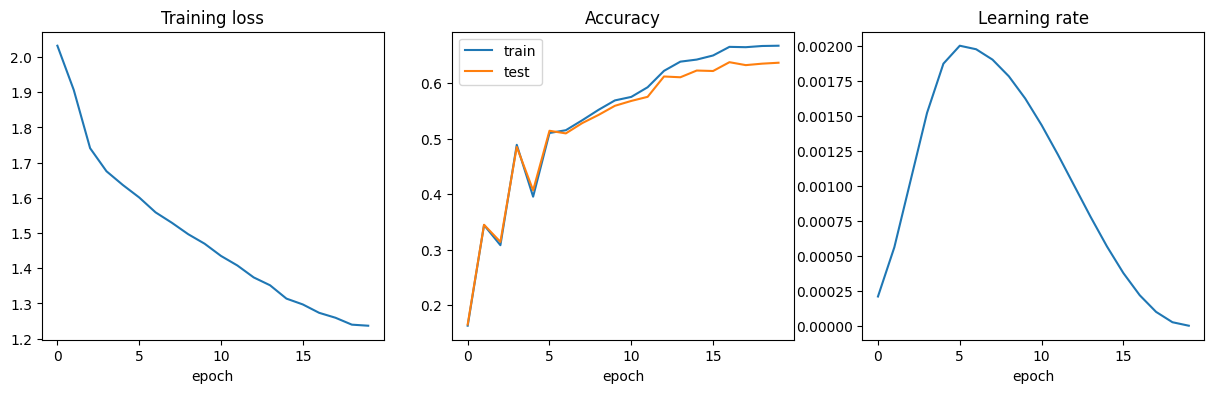

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(history["loss"]); ax[0].set_title("Training loss")
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["test_acc"], label="test")
ax[1].set_title("Accuracy"); ax[1].legend()
ax[2].plot(history["lr"]); ax[2].set_title("Learning rate")

for a in ax: a.set_xlabel("epoch")
plt.show()